# AI-Based Government Scheme Recommendation System

Many people are unaware of the government schemes they are eligible for because finding relevant schemes is difficult and time-consuming. Citizens must search through multiple websites and understand complex eligibility rules.
The proposed AI-Based Government Scheme Recommendation System uses Machine Learning to analyze user details such as age, gender, income, education, occupation, and location to recommend the most suitable government schemes with confidence scores. The system helps users quickly discover personalized welfare schemes in an easy and efficient way.

In [25]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression 
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [26]:
df = pd.read_csv("Dataset.csv")

In [27]:
df.shape

(3400, 10)

In [28]:
df.dtypes

scheme_name       object
slug              object
details           object
benefits          object
eligibility       object
application       object
documents         object
level             object
schemeCategory    object
tags              object
dtype: object

In [29]:
df.isnull().sum()

scheme_name        0
slug               0
details            0
benefits           0
eligibility        0
application        2
documents         11
level              0
schemeCategory     0
tags              29
dtype: int64

In [30]:
cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [31]:
df.isnull().sum()

scheme_name       0
slug              0
details           0
benefits          0
eligibility       0
application       0
documents         0
level             0
schemeCategory    0
tags              0
dtype: int64

In [32]:
df.drop_duplicates()


,scheme_name,slug,details,benefits,eligibility,application,documents,level,schemeCategory,tags
0,"""Immediate Relief Assistance"" under ""Welfare a...",ira-wrflsncs,"The scheme ""Immediate Relief Assistance"" is a ...","₹ 1,00,000, in two installments of ₹ 50,000 ea...",The applicant should be the family (legal heir...,Step 1: The interested applicant should visit ...,Photograph of the Family (Legal Heir) of the M...,State,"Agriculture,Rural & Environment, Social welfar...","Missing, Fisherman, Relief, Financial Assistan..."
1,AICTE SHORT TERM TRAINING PROGRAMME-SFURTI SCHEME,astpss,"Short Term Training Programme-SFURTI Program, ...","Financial Assistance : Limit of funding ₹ 4,00...",The institution should be AICTE approved.,Registration of New Institute: Step 01: Visit ...,Feedback Form Copy of Proceedings Completion R...,Central,Education & Learning,"Trainings, Financial Assistance, AICTE"
2,Burial and Ex-gratia Payment Scheme in Case of...,baepsicodouldwact,"Launched in 2014, the "" Burial and Ex-gratia P...","Funeral Assistance: ₹3,000 payable in case of ...",The deceased construction worker should have b...,Step 1: The interested applicant should visit ...,Aadhaar Card of the applicant (nominee/Legal h...,State,Social welfare & Empowerment,"Building Worker, Construction Workers, Unregis..."
3,Consortia & Tender Marketing Scheme,ctms,Promotion of the product of Micro and Small En...,Enlistment of the Unit for participating in Go...,Micro & Small Enterprises registered with NSIC...,"Step 01: The application form, in the prescrib...",A passport size photograph of each of the Prop...,Central,Business & Entrepreneurship,"Goods And Services Marketing, Turnkey Projects..."
4,Garuda Scheme for Funeral Expense,gsfe,Andhra Pradesh Brahmin Welfare Corporation (AB...,"Financial Assistance of ₹10,000/- for funeral ...",The applicant should be a close relative of th...,Registration and apply Step 01: Applicants hav...,Passport-size Photograph of the Applicant Aadh...,State,Social welfare & Empowerment,"Social Welfare, Financial Assistance, Deceased..."
...,...,...,...,...,...,...,...,...,...,...
3395,“Ishan Uday” Special Scholarship Scheme For No...,iu-sss-ner,A scholarship scheme by the Ministry of Educat...,"1) UGC will award 10,000 (ten thousand) fresh...",The applicant must be a domicile of NER. The p...,New Registration : Step 1: Visit the Registrat...,Domicile certificate to be issued by the compe...,Central,Education & Learning,"Scholarship, Financial Assistance"
3396,“Medical Camps (Allopathy and Indian systems o...,mcacism-giapsca,The sub-scheme “Medical Camps (Allopathy and I...,Free Health Checkup and Free Medicines. Awaren...,The applicant should be 60 years or above in a...,Step 1: The interested applicant should visit ...,Aadhaar Card. Birth Certificate / Age Proof. R...,State,Health & Wellness,"Medicine, Health, Checkup, Senior Citizen, Doctor"
3397,“RAKSHAK PURASKARS’’ Award,rpa,The Directorate of Women and Child Development...,The recipients of the awarded are given a scro...,The applicant should have shown exceptional co...,Step 1: In the prescribed format of the applic...,Passport Size Photograph (Duly Attested by a G...,State,"Social welfare & Empowerment, Public Safety,La...","Award, Crime, Women, Girl, Violence, Harrassment"
3398,"“Training in Coir” Component of the ""Developme...",ticcotdocs,The scheme “Training in Coir” Component of the...,"Stipend of ₹1,500 per month per trainee during...",The applicant should be a native of Puducherry...,Step 1: The interested applicant should take p...,Residential Certificate (for verifying native ...,State,Skills & Employment,"Skill, Training, Coir, Rural, Poor, Employment"


C:\Users\solan\AppData\Local\Temp\ipykernel_12924\4172295038.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='level', order=df['level'].value_counts().index, palette='viridis')


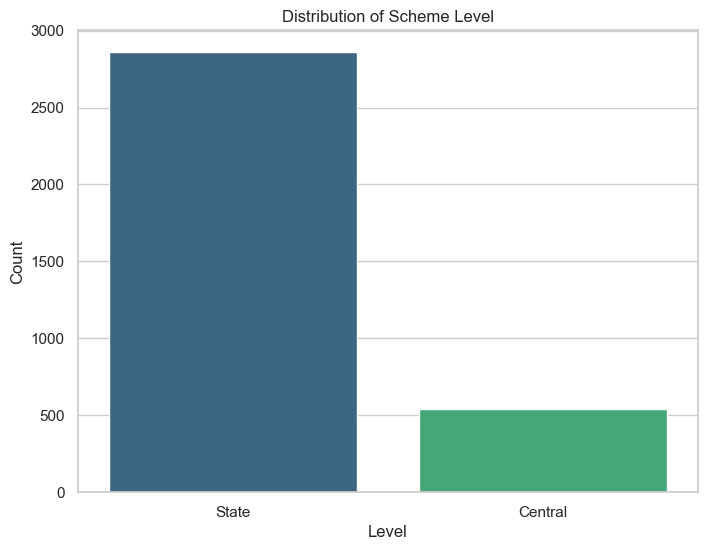

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 3. Distribution of 'level' (State vs. Central)
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='level', order=df['level'].value_counts().index, palette='viridis')
plt.title('Distribution of Scheme Level')
plt.xlabel('Level')
plt.ylabel('Count')
plt.savefig('level_distribution.png')


C:\Users\solan\AppData\Local\Temp\ipykernel_12924\3473655051.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_categories.values, y=top_categories.index, palette='magma')


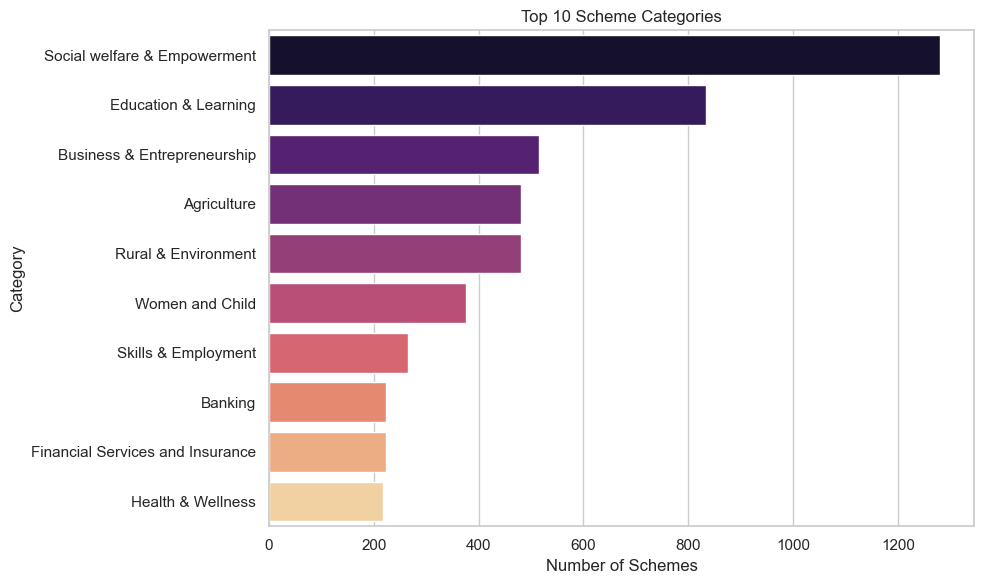

In [34]:
# 4. Top 10 Scheme Categories 
# (Handling entries with multiple categories separated by commas)
categories = df['schemeCategory'].dropna().str.split(',').explode().str.strip()
top_categories = categories.value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='magma')
plt.title('Top 10 Scheme Categories')
plt.xlabel('Number of Schemes')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig('top_categories.png')

C:\Users\solan\AppData\Local\Temp\ipykernel_12924\962742109.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tags.values, y=top_tags.index, palette='coolwarm')


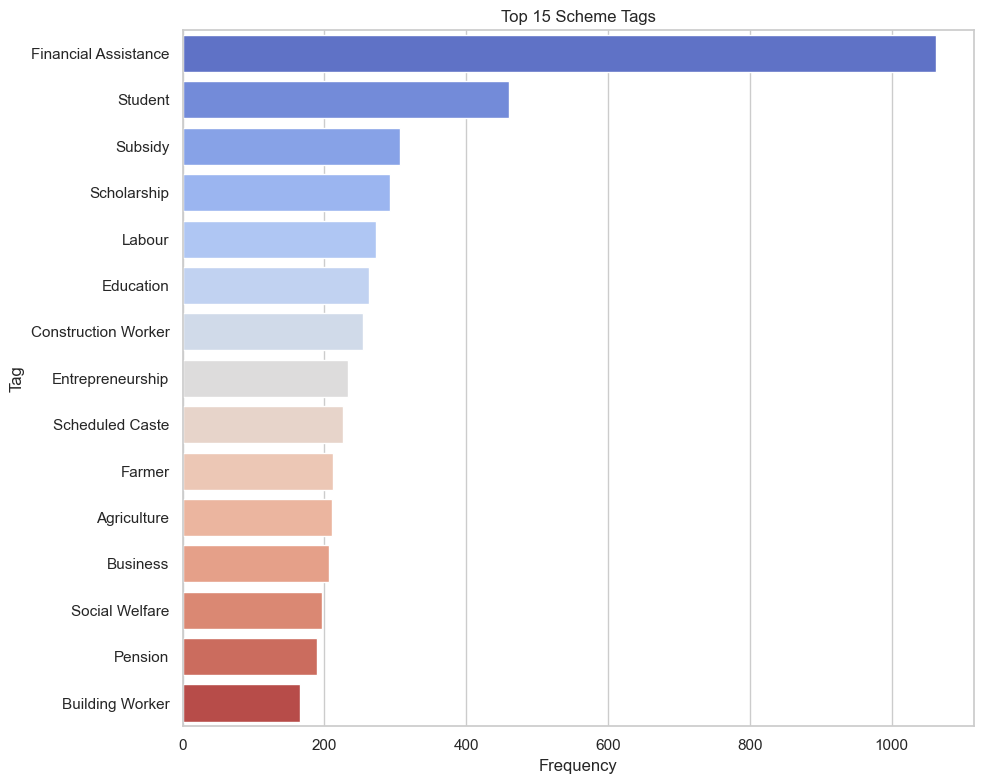

In [35]:
# 5. Top 15 Scheme Tags
tags = df['tags'].dropna().str.split(',').explode().str.strip()
top_tags = tags.value_counts().head(15)

plt.figure(figsize=(10, 8))
sns.barplot(x=top_tags.values, y=top_tags.index, palette='coolwarm')
plt.title('Top 15 Scheme Tags')
plt.xlabel('Frequency')
plt.ylabel('Tag')
plt.tight_layout()
plt.savefig('top_tags.png')


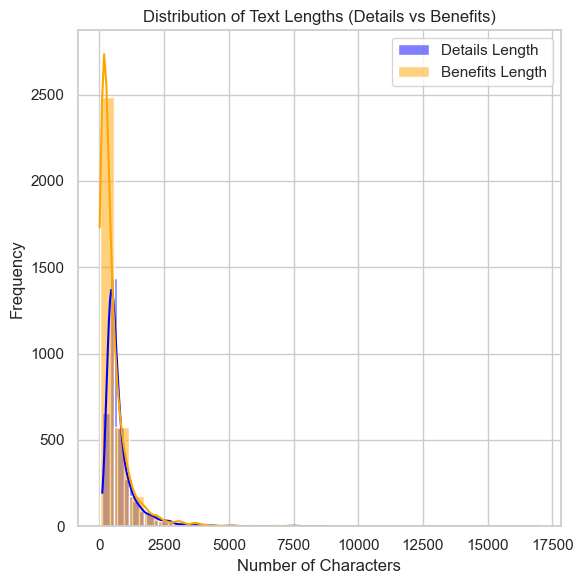

In [36]:
# 7. Text Length Analysis (Information Density)
# Calculate length of text in specific columns
df['details_len'] = df['details'].str.len()
df['benefits_len'] = df['benefits'].str.len()

plt.figure(figsize=(6, 6))
sns.histplot(df['details_len'].dropna(), bins=30, kde=True, label='Details Length', alpha=0.5, color='blue')
sns.histplot(df['benefits_len'].dropna(), bins=30, kde=True, label='Benefits Length', alpha=0.5, color='orange')
plt.title('Distribution of Text Lengths (Details vs Benefits)')
plt.xlabel('Number of Characters')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('text_length_distribution.png')


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(stop_words="english", max_features=5000)
X_vectorized = vectorizer.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y_encoded,
    test_size=0.2,
    random_state=42
)

In [ ]:
logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_accuracy = accuracy_score(y_test, logistic_pred)


In [ ]:
print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.6088235294117647


In [43]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.6073529411764705


In [47]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test,logistic_pred )
cm

array([[89,  0,  0, ...,  0,  0,  0],
       [ 4,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], dtype=int64)

In [ ]:

if rf_accuracy > logistic_accuracy:
    best_model = rf_model
    print("Random Forest Selected")
else:
    best_model = logistic_model
    print("Logistic Regression Selected")

# Save files

joblib.dump(best_model, "scheme_model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")
joblib.dump(label_encoder, "label_encoder.pkl")

print("Model Saved Successfully")

Logistic Regression Selected
Model Saved Successfully
